In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('train_nn.csv')

In [ ]:
df.drop('target_cls',axis =1,inplace = True)

In [ ]:
df = df.iloc[: ,1:]

In [ ]:
df.describe()

,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,F_10,...,F_12,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20,target_reg
count,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,...,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000,16000.000000
mean,4.024687,7.042125,5.121250,5.377063,3.506250,6.897625,7.494375,4.635063,5.180125,8.287437,...,7.929437,3.045437,8.334500,3.690937,7.802500,16.080725,6.475156,4.718224,49.390275,7.273268
std,1.911820,3.303583,2.016384,2.266237,2.190037,2.030739,2.325872,2.710967,2.391477,2.491426,...,2.083112,2.332158,1.543295,2.566092,1.616913,6.331444,2.989346,2.213400,27.644889,1.943970
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.900000,0.070000
25%,3.000000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,7.000000,...,7.000000,1.000000,8.000000,2.000000,7.000000,12.560000,5.000000,3.350000,32.100000,6.000000
50%,4.000000,7.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,8.000000,...,8.000000,3.000000,8.000000,3.000000,8.000000,15.700000,6.250000,4.690000,43.800000,7.360000
75%,5.000000,9.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,10.000000,...,9.000000,4.000000,9.000000,5.000000,8.000000,18.840000,8.750000,6.030000,63.300000,8.630000
max,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,47.100000,18.750000,10.050000,156.300000,14.990000


In [ ]:
df.shape

(16000, 21)

In [ ]:
df['F_17'] = df['F_17']/3

In [ ]:
df['F_20'] = df['F_20']/10

In [ ]:
metric = pd.DataFrame({'label' : df.columns,
              'mean' : np.mean(df,axis =0),
              'std' : np.std(df,axis = 0)})

In [ ]:
for col in df.columns:
  df = df[~(df[col].isna())]

In [ ]:
for col in df.columns:
  df[col] = (df[col] - np.mean(df[col]))/np.std(df[col])

In [ ]:
for col in df.columns:
  if col == 'target_reg':
    continue
  df = df[df[col] < 3]

In [ ]:
testdf = df.sample(frac = 0.1,random_state=42)
df.drop(testdf.index,inplace = True)

In [ ]:
xs = df.drop(['target_reg'],axis = 1)
reg_targets = df.target_reg
txs = testdf.drop(['target_reg'],axis = 1)
target = testdf.target_reg


In [ ]:
class Neuron:
    def __init__(self, data,children = (),_backward = lambda : None):
        self.data = data
        self.grad = 0.0
        self.children = children
        self._backward = lambda : None
    def __mul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data*other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    def __add__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __sub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out
    def relu(self):
        out = Neuron(self.data) if self.data > 0 else Neuron(0)
        out.children = (self,)
        def _backward():
            self.grad += out.grad*1 if self.data > 0 else 0
        out._backward = _backward
        return out
    def __truediv__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        def _backward():
            self.grad += out.grad/other.data
            other.grad += -(self.data / (other.data ** 2)) * out.grad
        try:
            out = self.data/other.data
            return Neuron(out , children = (self,other),_backward = _backward)
        except ZeroDivisionError:
            out = Neuron(0)
        def _backward():
            self.grad += out.grad/other.data
            other.grad += -(self.data / (other.data ** 2)) * out.grad
        out.children = (self,other)
        out._backward = _backward
        return out
    def __pow__(self,other : float):
        # other = other if isinstance(other,Neuron) else Neuron(other) we are not doing this cuz
        # if other.data < 0 we might have to face a problem of get undefined
        # to avoid that I am considering other over here as an int variable only
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out = Neuron(self.data**other)
        out.children = (self,)
        out._backward = _backward
        return out
    def __radd__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data + other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad += 1.0*out.grad
        out._backward = _backward
        return out
    def __rsub__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data - other.data)
        out.children = (self,other)
        def _backward():
            self.grad += 1.0*out.grad
            other.grad -= 1.0*out.grad
        out._backward = _backward
        return out
    def __rmul__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        out = Neuron(self.data * other.data)
        out.children = (self,other)
        def _backward():
            self.grad += other.data*out.grad
            other.grad += self.data*out.grad
        out._backward = _backward
        return out
    def __rtruediv__(self,other):
        other = other if isinstance(other,Neuron) else Neuron(other)
        def _backward():
            self.grad += out.grad/other.data
            other.grad += -(self.data / (other.data ** 2)) * out.grad
        try:
            out = self.data/other.data
            return Neuron(out,children = (self,other),_backward = _backward)
        except ZeroDivisionError:
            out = Neuron(0)
        out.children = (self,other)
        out._backward = _backward
        return out
    def __rpow__(self,other : float):
        out = Neuron(self.data**other)
        def _backward():
            self.grad += (other*(self.data**(other - 1)))*out.grad
        out.children = (self,other)
        out._backward = _backward
        return out
    def __neg__(self):
        out = Neuron(-self.data)
        out.children = (self,)
        def _backward():
            self.grad += -1.0*out.grad
        out._backward = _backward
        return out
    def tanh(self):
        out = Neuron((np.exp(2*self.data) - 1)/(np.exp(2*self.data) + 1))
        out.children = (self,)
        def _backward():
            self.grad += out.grad*(1 - out.data ** 2)
        out._backward = _backward
        return out
    def __repr__(self):
        return f"Neuron({self.data} grad {self.grad})"
    def backward(self):
    # seed gradient at loss
      self.grad = 1.0

      topo = []
      visited = set()
      stack = [(self, 0)]  # (node, state) where state=0 -> first time, state=1 -> after children

      while stack:
          n, state = stack.pop()
          if state == 0:
              if n in visited:
                  continue
              visited.add(n)
              # post-order: push (n,1) then its children with state 0
              stack.append((n, 1))
              for child in n.children:
                  if child not in visited:
                      stack.append((child, 0))
          else:
              # all children processed; now append to topo
              topo.append(n)

      # same as before
      for n in reversed(topo):
          n._backward()
class Module:

    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0

    def parameters(self):
        return []

class Node(Module):

    def __init__(self, nin, nonlin=True):
        # intializing the default mode be a relu unit with He activation
        self.w = [Neuron(np.random.normal(0,np.sqrt(2/nin))) for _ in range(nin)]
        self.b = Neuron(0)
        self.nin = nin
        self.nonlin = nonlin

    def __call__(self, x):
        act = sum((wi*xi for wi,xi in zip(self.w, x)), self.b)
        return act.relu() if self.nonlin else act

    def parameters(self):
        return self.w + [self.b]

    def __repr__(self):
        return f"{'ReLU' if self.nonlin else 'Linear'}Neuron({len(self.w)})"

class Layer(Module):

    def __init__(self, nin, nout,weight_intializer = 'He' ,nonlin = False ,**kwargs):
        self.neurons = [Node(nin, nonlin) for _ in range(nout)]
        def He():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / neuron.nin))) for _ in range(neuron.nin)]
        def Xavier():
            for neuron in self.neurons:
                neuron.w = [Neuron(np.random.normal(0, np.sqrt(2 / (neuron.nin + nout)))) for _ in range(neuron.nin)]
        if weight_intializer == 'He':
            He()
        elif weight_intializer == 'Xavier':
            Xavier()
        else:
            raise ValueError(f'Unknown weight initialization : {weight_intializer}')

    def __call__(self, x):
        out = [n(x) for n in self.neurons]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()]

    def __repr__(self):
        return f"Layer of [{', '.join(str(n) for n in self.neurons)}]"

class MLP(Module):

    def __init__(self, Layers):
        self.x = None
        self.y = None
        self.layers = Layers
        self.params = self.parameters()

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def __repr__(self):
        return f"MLP of [{', '.join(str(layer) for layer in self.layers)}]"

    def fit(self,x,y,optimizer = 'adam',epochs = 1000):
        self.x = x
        self.y = y
        self.optimizer = optimizer
        y_pred = [self(xs) for xs in self.x]
        cost = sum((yout - ygt) ** 2 for ygt, yout in zip(self.y, y_pred))
        self.m = [0]*len(self.parameters())
        self.v = [0]*len(self.parameters())
        self.epoch = 1
        self.epoch_limit = epochs

        def adam(learning_rate = 0.01):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            hat_m = [_m / (1 - 0.9 ** self.epoch) for _m in self.m]
            hat_v = [_v / (1 - 0.999 ** self.epoch) for _v in self.v]
            r_v = [np.sqrt(1/(_hat_v + 0.1**4)) for _hat_v in hat_v]
            for params,_hat_m,_r_v in zip(self.parameters(),hat_m,r_v):
                params.data -= learning_rate*_hat_m*_r_v

        def RMSprop(learning_rate = 0.001):
            self.v =[0.999*v1 + 0.001*(grad**2) for v1,grad in zip(self.v, [p.grad for p in self.parameters()])]
            r_v = [(1/(np.sqrt(_hat_v) + 0.1**4)) for _hat_v in self.v]
            for params,_r_v in zip(self.parameters(),r_v):
                params.data -= learning_rate*_r_v*params.grad

        def momentum(learning_rate = 0.01):
            self.m =[0.9*w1 + 0.1*grad for w1,grad in zip(self.m, [p.grad for p in self.parameters()])]
            for params,_hat_m in zip(self.parameters(),self.m):
                params.data -= learning_rate*_hat_m

        if self.optimizer == 'adam':
            update_step = adam
        elif self.optimizer =='RMSprop':
            update_step = RMSprop
        elif self.optimizer =='momentum':
            update_step = momentum
        else:
            raise ValueError(f'Unknown Optimizer : {self.optimizer}')
        loss = []
        lr = 0.005
        patience = 0
        while self.epoch <= self.epoch_limit:
            self.zero_grad()
            y_pred = [self(xs) for xs in self.x]
            cost = sum([(yout - ygt) ** 2 for ygt, yout in zip(self.y, y_pred)])
            cost = cost * (1.0/len(y_pred))
            cost.backward()
            update_step(lr)
            print(f"Epoch {self.epoch} | Loss: {cost.data}")
            loss.append(cost.data)
            self.epoch += 1
            if ((len(loss) > 3 and np.abs((loss[-2] - loss[-1])/loss[-1]  < 0.05) and cost.data < 0.2 )and lr*0.8 >1e-5 ):
              lr = lr*0.8
              print(f"\n teduced lr to {lr}")
            if(len(loss) > 3 and loss[-2] < loss[-1]):
              patience += 1
              if (patience > 3 ) or cost.data < 0.01:
                patience = 0
                print("/n Early stopping")
                break
        return loss
    def predict(self,x):
      preds = []
      for xs in x:
          # convert to Neuron if needed
          xs_neuron = [Neuron(xi) if not isinstance(xi, Neuron) else xi for xi in xs]
          y_pred = self(xs_neuron)  # forward pass
          preds.append(y_pred.data)
      return preds
class BatchNorm1dNode(Module):

    def __init__(self, n_features):

        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features

    def __call__(self, x):

        assert len(x) == self.n_features

        mean = sum(x, Neuron(0.0)) / self.n_features
        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) / self.n_features
        std = (var + 1e-5) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"BatchNorm1dNode({self.n_features})"


class BatchNorm1d(Module):

    def __init__(self, n_features, **kwargs):
        self.nodes = [BatchNorm1dNode(n_features)]

    def __call__(self, x):
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"BatchNorm1d of [{', '.join(str(n) for n in self.nodes)}]"

class LayerNorm1dNode(Module):

    def __init__(self, n_features, eps=1e-5):
        # gamma and beta for each feature (like weights + bias)
        self.gamma = [Neuron(1.0) for _ in range(n_features)]
        self.beta  = [Neuron(0.0) for _ in range(n_features)]
        self.n_features = n_features
        self.eps = eps

    def __call__(self, x):

        assert len(x) == self.n_features


        mean = sum(x, Neuron(0.0)) * (1.0 / self.n_features)


        var_terms = [(xi - mean) ** 2 for xi in x]
        var = sum(var_terms, Neuron(0.0)) * (1.0 / self.n_features)

        std = (var + self.eps) ** 0.5

        out = []
        for xi, g, b in zip(x, self.gamma, self.beta):
            x_hat = (xi - mean) / std
            yi = g * x_hat + b
            out.append(yi)

        return out[0] if len(out) == 1 else out

    def parameters(self):
        return self.gamma + self.beta

    def __repr__(self):
        return f"LayerNorm1dNode({self.n_features})"

class LayerNorm1d(Module):


    def __init__(self, n_features, **kwargs):
        self.nodes = [LayerNorm1dNode(n_features)]

    def __call__(self, x):
        # x: list[Neuron] for ONE sample
        out = [n(x) for n in self.nodes]
        return out[0] if len(out) == 1 else out

    def parameters(self):
        return [p for n in self.nodes for p in n.parameters()]

    def __repr__(self):
        return f"LayerNorm1d of [{', '.join(str(n) for n in self.nodes)}]"




In [ ]:
model = MLP(
    (Layer(nin = 20,nout=1,nonlin = False),
    )
)


In [ ]:
model.params

[Neuron(-0.2737973969954205 grad 0.0),
 Neuron(-0.6187509714139857 grad 0.0),
 Neuron(-0.16353655704735748 grad 0.0),
 Neuron(-0.48012184278477454 grad 0.0),
 Neuron(-0.4499078536937511 grad 0.0),
 Neuron(-0.207541033315496 grad 0.0),
 Neuron(0.16187369654020267 grad 0.0),
 Neuron(-0.1663294608344439 grad 0.0),
 Neuron(-0.5345850735754566 grad 0.0),
 Neuron(0.20479969055135802 grad 0.0),
 Neuron(0.39505272785096957 grad 0.0),
 Neuron(0.15319409750034577 grad 0.0),
 Neuron(-0.2979583474325434 grad 0.0),
 Neuron(-0.11400413534957286 grad 0.0),
 Neuron(0.47541514194204265 grad 0.0),
 Neuron(-0.19410202695401627 grad 0.0),
 Neuron(-0.20594985601272395 grad 0.0),
 Neuron(-0.16117753645187644 grad 0.0),
 Neuron(0.2725453798581039 grad 0.0),
 Neuron(0.31693336000446615 grad 0.0),
 Neuron(0 grad 0.0)]

In [ ]:
a = []

In [ ]:

a += model.fit(xs.to_numpy(),reg_targets.to_numpy(),epochs = 100)
pred = model.predict(txs.to_numpy())

Epoch 1 | Loss: 1.3496053793933576
Epoch 2 | Loss: 1.335133630302902
Epoch 3 | Loss: 1.2464675503838532
Epoch 4 | Loss: 1.244664455661472
Epoch 5 | Loss: 1.1658319329454745
Epoch 6 | Loss: 1.1136166408391412
Epoch 7 | Loss: 1.0982989296037498
Epoch 8 | Loss: 1.0596388962909458
Epoch 9 | Loss: 1.0033465295436867
Epoch 10 | Loss: 0.9654446163706619
Epoch 11 | Loss: 0.9436940037840295
Epoch 12 | Loss: 0.911405189876573
Epoch 13 | Loss: 0.8682307635016987
Epoch 14 | Loss: 0.8331327876948114
Epoch 15 | Loss: 0.8101330959688421
Epoch 16 | Loss: 0.7849849226675601
Epoch 17 | Loss: 0.7518770206170422
Epoch 18 | Loss: 0.720902303828658
Epoch 19 | Loss: 0.6987298637594201
Epoch 20 | Loss: 0.678477567162016
Epoch 21 | Loss: 0.653279868804699
Epoch 22 | Loss: 0.6274447627696669
Epoch 23 | Loss: 0.6073019626213808
Epoch 24 | Loss: 0.5903994233104369
Epoch 25 | Loss: 0.5709519932485181
Epoch 26 | Loss: 0.5501051711166894
Epoch 27 | Loss: 0.5327317665660104
Epoch 28 | Loss: 0.5184274268954637
Epoch 2

In [37]:
testdf = pd.read_csv('test_nn.csv')

In [38]:
testdf.F_17 = testdf.F_17/3
testdf.F_20 = testdf.F_20/10

In [39]:
pred = model.predict(testdf.to_numpy())

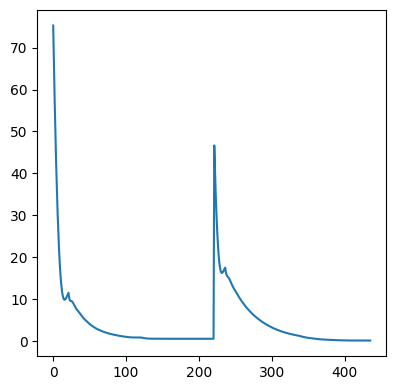

In [36]:
import matplotlib.pyplot as plt
plt.figure(figsize = (4.5,4.5))
plt.plot(a)

In [ ]:
xs.shape[1]

20

In [ ]:
reg_targets.shape

(16000,)

In [40]:
testdf.describe()

,Unnamed: 0,F_1,F_2,F_3,F_4,F_5,F_6,F_7,F_8,F_9,...,F_11,F_12,F_13,F_14,F_15,F_16,F_17,F_18,F_19,F_20
count,4000.000000,4000.000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,4000.000000,4000.00000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,1999.500000,4.019,7.009000,5.124250,5.354000,3.504250,6.897500,7.524750,4.602750,5.172750,...,6.472500,7.927250,3.04875,8.356250,3.695000,7.796000,5.363382,6.465937,4.696030,4.905075
std,1154.844867,1.919,3.308724,2.007566,2.242084,2.192415,2.007362,2.323411,2.655693,2.338006,...,2.650849,2.070877,2.33436,1.560431,2.571309,1.619889,2.101252,2.922508,2.216845,2.708107
min,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.090000
25%,999.750000,3.000,5.000000,4.000000,4.000000,2.000000,6.000000,6.000000,3.000000,4.000000,...,5.000000,7.000000,2.00000,8.000000,2.000000,7.000000,4.186667,5.000000,3.350000,3.210000
50%,1999.500000,4.000,7.000000,5.000000,6.000000,3.000000,7.000000,7.000000,4.000000,5.000000,...,6.000000,8.000000,3.00000,8.000000,3.000000,8.000000,5.233333,6.250000,4.690000,4.350000
75%,2999.250000,5.000,9.000000,6.000000,7.000000,5.000000,8.000000,9.000000,6.000000,7.000000,...,8.000000,9.000000,4.00000,9.000000,5.000000,9.000000,6.280000,8.750000,6.030000,6.330000
max,3999.000000,13.000,15.000000,13.000000,15.000000,15.000000,14.000000,15.000000,15.000000,15.000000,...,15.000000,15.000000,15.00000,15.000000,15.000000,14.000000,13.606667,18.750000,10.050000,15.630000


In [41]:
sdf = pd.DataFrame({'id' : testdf.iloc[:,0], 'pred' : pred })

In [42]:
sdf.to_csv('val_reg_nn.csv')